<a href="https://colab.research.google.com/github/Ayman-Ewas/Supervised-Assignment-2-CNN-/blob/main/20230081_2023_2023_CNN_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']
# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()
# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")


Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


In [ ]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
  epochs=20, batch_size=128, extra_callbacks=None):
  cb = extra_callbacks if extra_callbacks else []
  start = time.time()
  history = model.fit(x_tr, to_categorical(y_tr, 10),
  validation_data=(x_v, to_categorical(y_v, 10)),
  epochs=epochs, batch_size=batch_size,
  callbacks=cb, verbose=0)

  elapsed = time.time() - start
  test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
  print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time:{elapsed:.1f}s")
  return history, test_acc, test_loss, elapsed

In [ ]:
def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
  plt.figure(figsize=(10, 6))
  for h, lbl in zip(histories, labels):
    plt.plot(h.history[metric], label=lbl)
  plt.xlabel('Epoch')
  plt.ylabel(ylabel if ylabel else metric)
  plt.title(title)
  plt.legend()
  plt.grid(True)
  plt.show()

In [ ]:
def BaselineCNN():
  model = models.Sequential([
      layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
      layers.MaxPooling2D((2, 2)),
      layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
      layers.MaxPooling2D((2, 2)),
      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dense(10, activation='softmax')
  ])

  model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

  return model

In [ ]:
# Min-Max Scaler
from sklearn.preprocessing import MinMaxScaler
minMax = MinMaxScaler()

x_train_minMax = minMax.fit_transform(x_train.reshape(-1, 32*32*3))
x_val_minMax = minMax.transform(x_val.reshape(-1, 32*32*3))
x_test_minMax = minMax.transform(x_test.reshape(-1, 32*32*3))

# Reshaping
x_train_minMax = x_train_minMax.reshape(-1, 32, 32, 3)
x_val_minMax = x_val_minMax.reshape(-1, 32, 32, 3)
x_test_minMax = x_test_minMax.reshape(-1, 32, 32, 3)

In [ ]:
# Standrdiaztion
from sklearn.preprocessing import StandardScaler
standard = StandardScaler()

x_train_standard = standard.fit_transform(x_train.reshape(-1, 32*32*3))
x_val_standard = standard.transform(x_val.reshape(-1, 32*32*3))
x_test_standard = standard.transform(x_test.reshape(-1, 32*32*3))

# Reshaping
x_train_standard = x_train_standard.reshape(-1, 32, 32, 3)
x_val_standard = x_val_standard.reshape(-1, 32, 32, 3)
x_test_standard = x_test_standard.reshape(-1, 32, 32, 3)

In [ ]:
# Training normal data
model = BaselineCNN()
history, test_acc, test_loss, elapsed = train_and_evaluate(model, x_train, y_train, x_val, y_val, x_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.5790 | Test Loss: 2.8443 | Time:865.7s


In [ ]:
# Training minMax scaled data
model = BaselineCNN()
history_minMax, test_acc_minMax, test_loss_minMax, elapsed_minMax = train_and_evaluate(model, x_train_minMax, y_train, x_val_minMax, y_val, x_test_minMax, y_test)

Test Acc: 0.6553 | Test Loss: 1.5818 | Time:1363.3s


In [ ]:
# Training standardized data
model = BaselineCNN()
history_standard, test_acc_standard, test_loss_standard, elapsed_standard = train_and_evaluate(model, x_train_standard, y_train, x_val_standard, y_val, x_test_standard, y_test)

Test Acc: 0.6526 | Test Loss: 2.0862 | Time:1376.3s


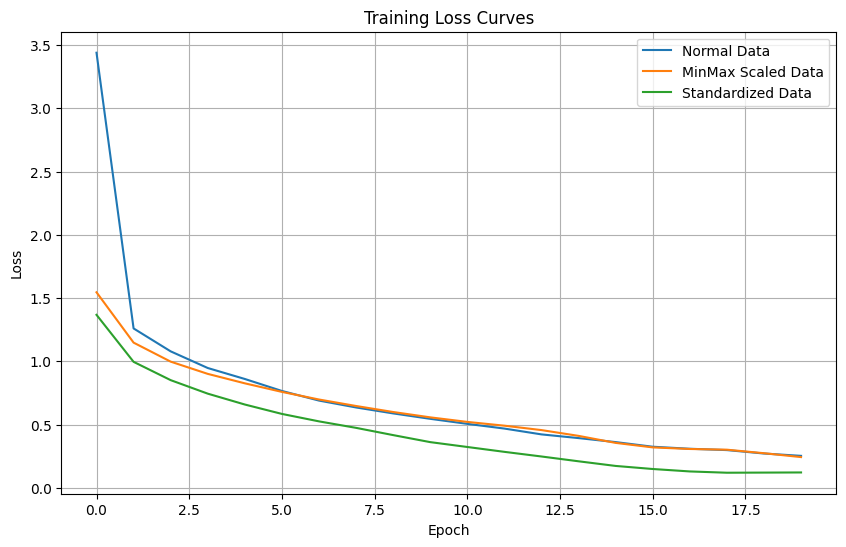

In [ ]:
# Plots
histories = [history, history_minMax, history_standard]
labels = ['Normal Data', 'MinMax Scaled Data', 'Standardized Data']

# Loss Plots
plot_curves(histories, labels, metric='loss', title='Training Loss Curves', ylabel='Loss')



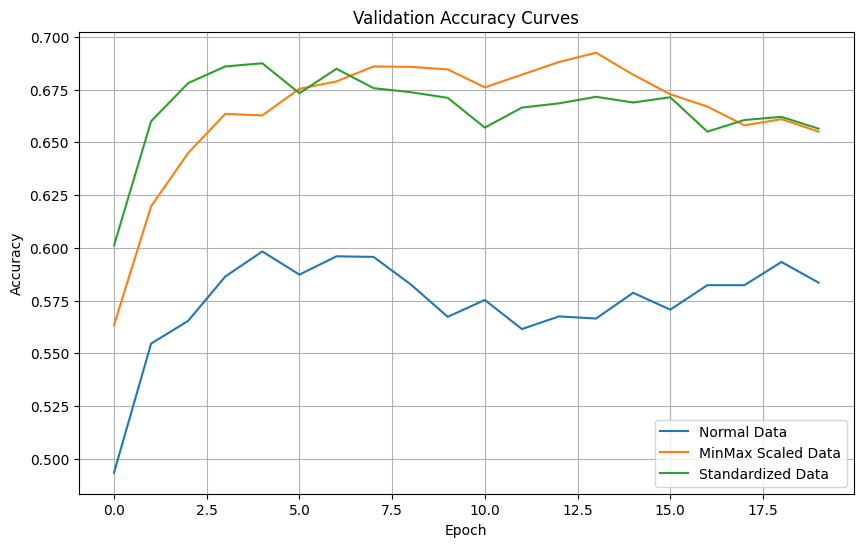

In [ ]:
# Accuracy plots
plot_curves(histories, labels, title='Validation Accuracy Curves', ylabel='Accuracy')

In [33]:
# Generating table
import pandas as pd
Data = {"Train Acc": [history.history['accuracy'], history_minMax.history['accuracy'], history_standard.history['accuracy']],
        "Val Acc" : [history.history['val_accuracy'], history_minMax.history['val_accuracy'], history_standard.history['val_accuracy']],
        "Test Acc": [test_acc, test_acc_minMax, test_acc_standard],
        "Loss @ epoch 1": [history.history['loss'][0], history_minMax.history['loss'][0], history_standard.history['loss'][0]]}
index = ["None [0-255]", "MinMax [0,1]", "Standardized"]
df = pd.DataFrame(Data, index=index)
df

,Train Acc,Val Acc,Test Acc,Loss @ epoch 1
None [0-255],"[0.39684998989105225, 0.5485749840736389, 0.61...","[0.4934000074863434, 0.5546000003814697, 0.565...",0.5790,3.438654
"MinMax [0,1]","[0.443574994802475, 0.5962749719619751, 0.6538...","[0.5633999705314636, 0.619700014591217, 0.6449...",0.6553,1.545659
Standardized,"[0.5152750015258789, 0.6547250151634216, 0.705...","[0.6011000275611877, 0.6600000262260437, 0.678...",0.6526,1.367492


In [ ]:
def Augmented():
  datagen = tf.keras.preprocessing.image.ImageDataGenerator(
  rotation_range=15,
  width_shift_range=0.1,
  height_shift_range=0.1,
  horizontal_flip=True,
  zoom_range=0.1
  )
  datagen.fit(x_train_standard)
  return datagen

In [ ]:
# Training with augmented data
model_aug = BaselineCNN()
datagen = Augmented()
augmented_train_generator = datagen.flow(x_train_standard, to_categorical(y_train, 10), batch_size=128)

start_aug = time.time()
history_aug = model_aug.fit(augmented_train_generator,
                            validation_data=(x_val_standard, to_categorical(y_val, 10)),
                            epochs=40,
                            verbose=0)
elapsed_aug = time.time() - start_aug

test_loss_aug, test_acc_aug = model_aug.evaluate(x_test_standard, to_categorical(y_test, 10), verbose=0)
print(f"Test Acc: {test_acc_aug:.4f} | Test Loss: {test_loss_aug:.4f} | Time: {elapsed_aug:.1f}s")

In [ ]:
# Training with standardized data (no augmented)
model = BaselineCNN()
history_non_aug, test_acc_non_aug, test_loss_non_aug, elapsed_non_aug = train_and_evaluate(model, x_train_standard, y_train, x_val_standard, y_val, x_test_standard, y_test, epochs=40)

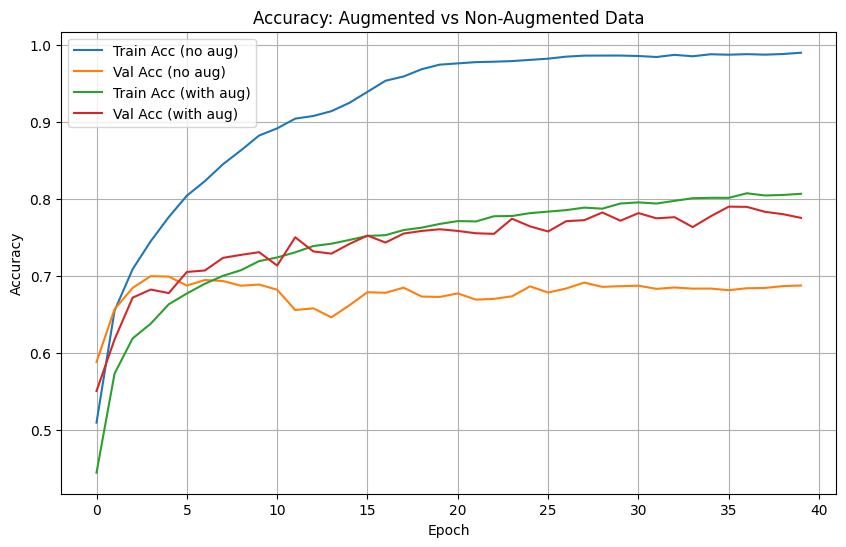

In [32]:
# Plotting 4 curves
plt.figure(figsize=(10, 6))
plt.plot(history_non_aug.history['accuracy'], label='Train Acc (no aug)')
plt.plot(history_non_aug.history['val_accuracy'], label='Val Acc (no aug)')
plt.plot(history_aug.history['accuracy'], label='Train Acc (with aug)')
plt.plot(history_aug.history['val_accuracy'], label='Val Acc (with aug)')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy: Augmented vs Non-Augmented Data')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
# Non-augmented gap
gap_non_aug = history_non_aug.history['accuracy'][39] - history_non_aug.history['val_accuracy'][39]

# Augmented gap
gap_aug = history_aug.history['accuracy'][39] - history_aug.history['val_accuracy'][39]

print(f"Non-Augmented gap at epoch 40: {gap_non_aug:.4f}")
print(f"Augmented gap at epoch 40: {gap_aug:.4f}")

# Augmentation reduced gap. Then, it overfits less

Non-Augmented gap at epoch 40: 0.3026
Augmented gap at epoch 40: 0.0313
